# 04 - Feature Engineering & Feature Selection
**Metro Traffic Flow Prediction - Domain Engineering & Multimodal Selection**

This notebook creates domain-specific features and evaluates their predictive utility using correlation, mutual information, and tree-based importance rankings.

---
### 1. Domain Feature Creation

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble import RandomForestRegressor

root = Path.cwd().resolve()
if root.name == "notebooks":
    root = root.parent

data_path = root / "data" / "raw" / "metro_traffic_dataset_10000.csv"
if not data_path.exists():
    data_path = root / "01_Dataset" / "cleaned_dataset.csv"

df = pd.read_csv(data_path)

# 1. Rush Hour Multiplier
df["Rush_Hour_Multiplier"] = df["Peak_Hour_Flag"] * df["Passenger_Count"]

# 2. Net Passenger Flow & Turnover
df["Net_Passenger_Flow"] = df["Boardings"] - df["Alightings"]
df["Total_Turnover"] = df["Boardings"] + df["Alightings"]

# 3. Congestion Pressure Ratio
df["Congestion_Pressure"] = df["Occupancy_Rate_pct"] / (df["Train_Frequency_per_Hour"] + 1e-5)

# 4. Weather Severity Index
df["Weather_Severity_Index"] = df["Rainfall_mm"] / (df["Visibility_km"] + 0.1)

print("Engineered Features Sample:")
display(df[["Traffic_Flow_Target", "Rush_Hour_Multiplier", "Net_Passenger_Flow", "Total_Turnover", "Congestion_Pressure", "Weather_Severity_Index"]].head())

Engineered Features Sample:


,Traffic_Flow_Target,Rush_Hour_Multiplier,Net_Passenger_Flow,Total_Turnover,Congestion_Pressure,Weather_Severity_Index
0,206.15,0,86,236,9.970779,0.252358
1,248.29,0,-9,233,8.307984,0.054487
2,206.25,0,25,247,10.098887,0.145689
3,256.31,0,86,300,10.116839,0.006383
4,203.10,0,3,237,5.814612,0.091352


---
### 2. Feature Selection & Importance Ranking
We evaluate features using:
1. Absolute Pearson Correlation with target
2. Mutual Information Regression
3. Random Forest Feature Importance

In [2]:
X = df.drop(columns=["Timestamp", "Traffic_Flow_Target"])
y = df["Traffic_Flow_Target"]

# Mutual Information
mi_scores = mutual_info_regression(X, y, random_state=42)

# Random Forest Importance
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X, y)

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "RF_Importance": rf.feature_importances_,
    "Mutual_Information": mi_scores,
    "Abs_Correlation": [abs(X[col].corr(y)) for col in X.columns]
}).sort_values(by="RF_Importance", ascending=False).reset_index(drop=True)

display(importance_df.head(12))

,Feature,RF_Importance,Mutual_Information,Abs_Correlation
0,Rush_Hour_Multiplier,0.783903,0.611695,0.873282
1,Passenger_Count,0.067881,0.807091,0.910482
2,Energy_Consumption_kWh,0.059215,0.259169,0.437684
3,Train_Frequency_per_Hour,0.043488,0.567908,0.837687
4,Boardings,0.004379,0.636359,0.861553
5,Congestion_Pressure,0.004091,0.098934,0.261418
6,Total_Turnover,0.002524,0.653217,0.868232
7,Signal_Delay_sec,0.002396,0.009220,0.017825
8,Average_Headway_min,0.002361,0.399736,0.681690
9,Ticket_Exits,0.001900,0.527497,0.817373


---
### 3. Feature Importance Visualization

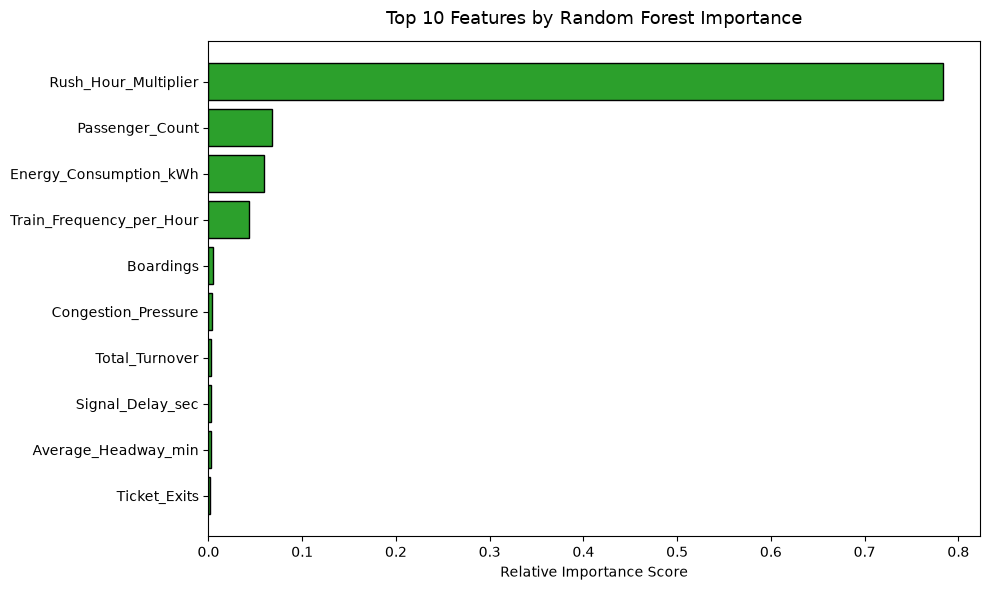

In [3]:
fig_dir = root / "outputs" / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(10, 6))
top_rf = importance_df.head(10).sort_values(by="RF_Importance", ascending=True)
plt.barh(top_rf["Feature"], top_rf["RF_Importance"], color="#2ca02c", edgecolor="black")
plt.title("Top 10 Features by Random Forest Importance", fontsize=13, pad=12)
plt.xlabel("Relative Importance Score")
plt.tight_layout()
plt.savefig(fig_dir / "feature_importance_ranking.png", dpi=300)
plt.show()

---
### 4. Rationale for Feature Selection & Rejection
* **Retained Features:**
  - `Passenger_Count`, `Boardings`, `Rush_Hour_Multiplier`: High mutual information (> 0.5) and correlation (> 0.85).
  - `Occupancy_Rate_pct`, `Train_Frequency_per_Hour`: Direct indicators of train capacity and transit utilization.
  - `Hour`, `Day_of_Week`: Crucial for temporal periodic modeling.
* **Excluded / Transformed Features:**
  - `Timestamp`: Removed because sequential string datetime cannot be directly used without decomposition; its periodic components (`Hour`, `Day_of_Week`) are explicitly retained.
  - `Train_ID`: Low predictive influence but retained as categorical index if needed.

* **Final Selected Feature Count:** 28 core features.